In [1]:
import ROOT
import math
import os
import pandas as pd
import numpy as np

%jsroot on

# ============================================================
# USER SETTINGS
# ============================================================

file_path = "/root/geant4/detector/Lung_Elements/HCO.root"
tree_name = "t"

selected_volume = 2
selected_pdg = 22                # gamma

E0 = 662.0                       # incident gamma energy, keV
ME = 511.0                       # electron rest energy, keV
P_AU = 3.72738                   # 1 a.u. momentum = 3.72738 keV/c

# GPS direction:
# /gps/direction 0 -1 0
incident_direction = (0.0, -1.0, 0.0)

# Histogram settings
n_theta_bins = 90                # 2-degree bins
n_energy_bins = 132              # ~5 keV/bin
n_Q_bins = 150

theta_min = 0.0
theta_max = 180.0

energy_min = 0.0
energy_max = E0

# Gaussian fitting
# Fit is automatically performed around the main Et peak.
fit_half_width_keV = 30.0

# Output files
event_csv_file = "HCO_vlm2_Q_theta_Et_events.csv"
summary_csv_file = "HCO_vlm2_summary.csv"


# ============================================================
# OPEN ROOT FILE
# ============================================================

if not os.path.exists(file_path):
    raise FileNotFoundError(
        f"ROOT file not found:\n{file_path}"
    )

root_file = ROOT.TFile.Open(file_path)

if not root_file or root_file.IsZombie():
    raise RuntimeError(
        f"Could not open ROOT file:\n{file_path}"
    )

tree = root_file.Get(tree_name)

if not tree:
    root_file.ls()
    raise RuntimeError(
        f"TTree '{tree_name}' was not found."
    )

print("ROOT file opened successfully")
print("File:", file_path)
print("Tree entries:", tree.GetEntries())


# ============================================================
# CHECK REQUIRED BRANCHES
# ============================================================

required_branches = [
    "pdg",
    "vlm",
    "trk",
    "stp",
    "k",
    "px",
    "py",
    "pz"
]

available_branches = {
    branch.GetName()
    for branch in tree.GetListOfBranches()
}

missing_branches = [
    name
    for name in required_branches
    if name not in available_branches
]

if missing_branches:
    raise RuntimeError(
        "Missing required branches: "
        + ", ".join(missing_branches)
    )

has_et_branch = "et" in available_branches

print("Required branches are available.")
print("Stored et branch available:", has_et_branch)


# ============================================================
# NORMALIZE INCIDENT DIRECTION
# ============================================================

ix, iy, iz = incident_direction

incident_norm = math.sqrt(
    ix**2 + iy**2 + iz**2
)

if incident_norm <= 0:
    raise ValueError(
        "Incident direction cannot be zero."
    )

ix /= incident_norm
iy /= incident_norm
iz /= incident_norm


# ============================================================
# STORAGE
# ============================================================

rows = []

all_vlm2_gamma_records = 0
unique_gamma_tracks = 0

invalid_energy_records = 0
zero_momentum_records = 0
invalid_q_records = 0
invalid_Q_records = 0


# ============================================================
# EVENT LOOP
# ============================================================

for event_number, event in enumerate(tree):

    # Do NOT include event.et here because et can have
    # a different vector length.
    n_core = min(
        len(event.pdg),
        len(event.vlm),
        len(event.trk),
        len(event.stp),
        len(event.k),
        len(event.px),
        len(event.py),
        len(event.pz)
    )

    # Keep the first record for each gamma track entering vlm 2
    counted_tracks = set()

    for i in range(n_core):

        # ----------------------------------------------------
        # SELECT VOLUME 2
        # ----------------------------------------------------

        if int(event.vlm[i]) != selected_volume:
            continue

        # Gamma only
        if int(event.pdg[i]) != selected_pdg:
            continue

        all_vlm2_gamma_records += 1

        track_id = int(event.trk[i])

        # Only first stored vlm=2 record for this gamma track
        if track_id in counted_tracks:
            continue

        counted_tracks.add(track_id)

        # ----------------------------------------------------
        # SCATTERED PHOTON ENERGY
        # ----------------------------------------------------

        Eprime_keV = float(event.k[i])

        if (
            not math.isfinite(Eprime_keV)
            or Eprime_keV <= 0.0
            or Eprime_keV > E0
        ):
            invalid_energy_records += 1
            continue

        # ----------------------------------------------------
        # ENERGY TRANSFER
        #
        # Et = E0 - E'
        # ----------------------------------------------------

        Et_keV = E0 - Eprime_keV

        # ----------------------------------------------------
        # OUTGOING PHOTON MOMENTUM
        # ----------------------------------------------------

        px = float(event.px[i])
        py = float(event.py[i])
        pz = float(event.pz[i])

        momentum = math.sqrt(
            px**2 +
            py**2 +
            pz**2
        )

        if (
            not math.isfinite(momentum)
            or momentum <= 0.0
        ):
            zero_momentum_records += 1
            continue

        ux = px / momentum
        uy = py / momentum
        uz = pz / momentum

        # ----------------------------------------------------
        # SCATTERING ANGLE
        #
        # theta = angle between incident and outgoing gamma
        # ----------------------------------------------------

        cos_theta = (
            ix * ux +
            iy * uy +
            iz * uz
        )

        cos_theta = max(
            -1.0,
            min(1.0, cos_theta)
        )

        theta_rad = math.acos(cos_theta)
        theta_deg = math.degrees(theta_rad)

        # ----------------------------------------------------
        # PHOTON MOMENTUM TRANSFER q
        #
        # q = sqrt(E0^2 + E'^2 - 2 E0 E' cos(theta))
        #
        # units: keV/c
        # ----------------------------------------------------

        q_squared = (
            E0**2
            + Eprime_keV**2
            - 2.0
            * E0
            * Eprime_keV
            * cos_theta
        )

        if (
            not math.isfinite(q_squared)
            or q_squared <= 0.0
        ):
            invalid_q_records += 1
            continue

        q_keV_c = math.sqrt(q_squared)

        # ----------------------------------------------------
        # LONGITUDINAL ELECTRON MOMENTUM Q
        #
        # Q = (ME/q) * [Et - q^2/(2ME)]
        #
        # First result: keV/c
        # Then convert to atomic units
        # ----------------------------------------------------

        Q_keV_c = (
            ME / q_keV_c
        ) * (
            Et_keV
            - q_squared / (2.0 * ME)
        )

        Q_au = Q_keV_c / P_AU

        if not math.isfinite(Q_au):
            invalid_Q_records += 1
            continue

        # ----------------------------------------------------
        # OPTIONAL STORED et VALUE
        # ----------------------------------------------------

        stored_et_keV = float("nan")

        if (
            has_et_branch
            and i < len(event.et)
        ):
            temp = float(event.et[i])

            if math.isfinite(temp):
                stored_et_keV = temp

        # ----------------------------------------------------
        # SAVE EVENT
        # ----------------------------------------------------

        rows.append({
            "event_number": event_number,
            "track_id": track_id,
            "record_index": i,
            "step_number": int(event.stp[i]),

            "vlm": int(event.vlm[i]),
            "pdg": int(event.pdg[i]),

            "E0_keV": E0,
            "Eprime_k_keV": Eprime_keV,
            "Et_E0_minus_Eprime_keV": Et_keV,

            "stored_et_keV": stored_et_keV,

            "theta_deg": theta_deg,
            "cos_theta": cos_theta,

            "q_gamma_keV_c": q_keV_c,

            "Q_keV_c": Q_keV_c,
            "Q_signed_au": Q_au,
            "Q_absolute_au": abs(Q_au),

            "px": px,
            "py": py,
            "pz": pz
        })

        unique_gamma_tracks += 1


# ============================================================
# CREATE DATAFRAME
# ============================================================

df = pd.DataFrame(rows)

print("\n========================================")
print("SELECTION SUMMARY")
print("========================================")

print("Selected volume:", selected_volume)
print("Selected PDG:", selected_pdg)
print("No process-selection cut")

print("\nAll vlm=2 gamma records:",
      all_vlm2_gamma_records)

print("Unique valid vlm=2 gamma tracks:",
      unique_gamma_tracks)

print("Invalid energy records:",
      invalid_energy_records)

print("Zero momentum records:",
      zero_momentum_records)

print("Invalid q records:",
      invalid_q_records)

print("Invalid Q records:",
      invalid_Q_records)


if df.empty:
    root_file.Close()

    raise RuntimeError(
        "No valid gamma records found in volume 2."
    )


# ============================================================
# PRINT RANGES
# ============================================================

print("\n========================================")
print("DATA RANGES")
print("========================================")

print(
    "theta:",
    df["theta_deg"].min(),
    "to",
    df["theta_deg"].max(),
    "degree"
)

print(
    "Et:",
    df["Et_E0_minus_Eprime_keV"].min(),
    "to",
    df["Et_E0_minus_Eprime_keV"].max(),
    "keV"
)

print(
    "Signed Q:",
    df["Q_signed_au"].min(),
    "to",
    df["Q_signed_au"].max(),
    "a.u."
)


# ============================================================
# SAVE EVENT CSV
# ============================================================

df = df.round(6)

df.to_csv(
    event_csv_file,
    index=False
)

print("\nEvent CSV saved:")
print(os.path.abspath(event_csv_file))


# ============================================================
# DETERMINE Q RANGE
# ============================================================

Q_abs_limit = max(
    abs(float(df["Q_signed_au"].min())),
    abs(float(df["Q_signed_au"].max()))
)

# Avoid pathological range
if Q_abs_limit <= 0:
    Q_abs_limit = 1.0

Q_min = -Q_abs_limit
Q_max = Q_abs_limit


# ============================================================
# REMOVE OLD ROOT OBJECTS
# ============================================================

object_names = [
    "h_theta_Et",
    "h_Et_counts",
    "g_Q_Et",
    "g3_theta_Q_Et",
    "c_HCO_vlm2"
]

for name in object_names:

    obj = ROOT.gROOT.FindObject(name)

    if obj:
        if obj.InheritsFrom("TCanvas"):
            obj.Close()
        else:
            obj.Delete()


# ============================================================
# CREATE HISTOGRAMS / GRAPHS
# ============================================================

# ------------------------------------------------------------
# PLOT 1
# theta versus Et
# ------------------------------------------------------------

h_theta_Et = ROOT.TH2F(
    "h_theta_Et",
    "Volume 2: scattering angle versus energy transfer;"
    "Scattering angle #theta (degrees);"
    "E_{t}=E_{0}-E' (keV);"
    "Counts",
    n_theta_bins,
    theta_min,
    theta_max,
    n_energy_bins,
    energy_min,
    energy_max
)

h_theta_Et.SetStats(0)


# ------------------------------------------------------------
# PLOT 2
# Et versus counts
# ------------------------------------------------------------

h_Et_counts = ROOT.TH1F(
    "h_Et_counts",
    "Volume 2: energy-transfer spectrum;"
    "E_{t}=E_{0}-E' (keV);"
    "Counts per bin",
    n_energy_bins,
    energy_min,
    energy_max
)


# ------------------------------------------------------------
# PLOT 3
# 3D: theta vs Q vs Et
# ------------------------------------------------------------

g3_theta_Q_Et = ROOT.TGraph2D()

g3_theta_Q_Et.SetName(
    "g3_theta_Q_Et"
)

g3_theta_Q_Et.SetTitle(
    "Volume 2: #theta versus signed Q versus E_{t};"
    "Scattering angle #theta (degrees);"
    "Signed Q (a.u.);"
    "E_{t}=E_{0}-E' (keV)"
)


# ------------------------------------------------------------
# PLOT 2
# Q versus Et
# ------------------------------------------------------------

g_Q_Et = ROOT.TGraph()

g_Q_Et.SetName(
    "g_Q_Et"
)

g_Q_Et.SetTitle(
    "Volume 2: energy transfer versus signed Q;"
    "Signed Q (a.u.);"
    "E_{t}=E_{0}-E' (keV)"
)


# ============================================================
# FILL HISTOGRAMS / GRAPHS
# ============================================================

for index, row in df.iterrows():

    theta = float(
        row["theta_deg"]
    )

    Et = float(
        row["Et_E0_minus_Eprime_keV"]
    )

    Q = float(
        row["Q_signed_au"]
    )

    h_theta_Et.Fill(
        theta,
        Et
    )

    h_Et_counts.Fill(
        Et
    )

    point_number = g_Q_Et.GetN()

    g_Q_Et.SetPoint(
        point_number,
        Q,
        Et
    )

    point_number_3d = g3_theta_Q_Et.GetN()

    g3_theta_Q_Et.SetPoint(
        point_number_3d,
        theta,
        Q,
        Et
    )


# ============================================================
# GAUSSIAN FIT TO Et SPECTRUM
# ============================================================

peak_bin = h_Et_counts.GetMaximumBin()

peak_energy = h_Et_counts.GetBinCenter(
    peak_bin
)

fit_min = max(
    energy_min,
    peak_energy - fit_half_width_keV
)

fit_max = min(
    energy_max,
    peak_energy + fit_half_width_keV
)

gaussian_fit = ROOT.TF1(
    "gaussian_fit",
    "gaus",
    fit_min,
    fit_max
)

# Reasonable initial values
gaussian_fit.SetParameters(
    h_Et_counts.GetMaximum(),
    peak_energy,
    max(h_Et_counts.GetRMS(), 1.0)
)

fit_result = h_Et_counts.Fit(
    gaussian_fit,
    "RSQ"
)

fit_amplitude = gaussian_fit.GetParameter(0)
fit_mean = gaussian_fit.GetParameter(1)
fit_sigma = abs(
    gaussian_fit.GetParameter(2)
)

fit_mean_error = gaussian_fit.GetParError(1)
fit_sigma_error = gaussian_fit.GetParError(2)

# Gaussian FWHM
FWHM = (
    2.0
    * math.sqrt(2.0 * math.log(2.0))
    * fit_sigma
)

FWHM_error = (
    2.0
    * math.sqrt(2.0 * math.log(2.0))
    * fit_sigma_error
)

# Equivalent:
# FWHM ≈ 2.35482 sigma


print("\n========================================")
print("GAUSSIAN FIT RESULTS")
print("========================================")

print(
    f"Peak-bin center = "
    f"{peak_energy:.6f} keV"
)

print(
    f"Fit range = "
    f"{fit_min:.6f} to {fit_max:.6f} keV"
)

print(
    f"Gaussian mean = "
    f"{fit_mean:.6f} ± "
    f"{fit_mean_error:.6f} keV"
)

print(
    f"Gaussian sigma = "
    f"{fit_sigma:.6f} ± "
    f"{fit_sigma_error:.6f} keV"
)

print(
    f"FWHM = "
    f"{FWHM:.6f} ± "
    f"{FWHM_error:.6f} keV"
)

if fit_mean != 0:

    resolution_percent = (
        FWHM / abs(fit_mean)
    ) * 100.0

    print(
        f"FWHM / mean = "
        f"{resolution_percent:.4f} %"
    )
else:
    resolution_percent = float("nan")


# ============================================================
# SAVE SUMMARY CSV
# ============================================================

summary_df = pd.DataFrame({
    "quantity": [
        "number_of_valid_gamma_tracks",
        "Et_peak_bin_keV",
        "Gaussian_mean_keV",
        "Gaussian_mean_error_keV",
        "Gaussian_sigma_keV",
        "Gaussian_sigma_error_keV",
        "Gaussian_FWHM_keV",
        "Gaussian_FWHM_error_keV",
        "FWHM_over_mean_percent"
    ],

    "value": [
        len(df),
        peak_energy,
        fit_mean,
        fit_mean_error,
        fit_sigma,
        fit_sigma_error,
        FWHM,
        FWHM_error,
        resolution_percent
    ]
})

summary_df = summary_df.round(6)

summary_df.to_csv(
    summary_csv_file,
    index=False
)

print("\nSummary CSV saved:")
print(os.path.abspath(summary_csv_file))


# ============================================================
# CANVAS
# ============================================================

c_HCO_vlm2 = ROOT.TCanvas(
    "c_HCO_vlm2",
    "HCO volume 2 analysis",
    1700,
    1200
)

c_HCO_vlm2.Divide(
    2,
    2
)


# ============================================================
# PLOT 1
# THETA vs Et
# ============================================================

pad1 = c_HCO_vlm2.cd(1)

pad1.SetLeftMargin(0.12)
pad1.SetRightMargin(0.16)
pad1.SetBottomMargin(0.12)

h_theta_Et.Draw(
    "COLZ"
)


# ============================================================
# PLOT 2
# Et vs COUNTS + GAUSSIAN + FWHM
# ============================================================

pad2 = c_HCO_vlm2.cd(2)

pad2.SetLeftMargin(0.12)
pad2.SetRightMargin(0.05)
pad2.SetBottomMargin(0.12)

h_Et_counts.SetStats(0)

h_Et_counts.Draw(
    "HIST"
)

gaussian_fit.Draw(
    "SAME"
)

# Text box containing fit result
fit_text = ROOT.TPaveText(
    0.55,
    0.60,
    0.88,
    0.88,
    "NDC"
)

fit_text.SetFillStyle(0)
fit_text.SetBorderSize(1)
fit_text.SetTextSize(0.035)

fit_text.AddText(
    f"Mean = {fit_mean:.3f} keV"
)

fit_text.AddText(
    f"#sigma = {fit_sigma:.3f} keV"
)

fit_text.AddText(
    f"FWHM = {FWHM:.3f} keV"
)

if math.isfinite(resolution_percent):

    fit_text.AddText(
        f"FWHM/Mean = "
        f"{resolution_percent:.3f}%"
    )

fit_text.Draw()


# ============================================================
# PLOT 3
# 3D: theta vs Q vs Et
# ============================================================

pad3 = c_HCO_vlm2.cd(3)

pad3.SetLeftMargin(0.12)
pad3.SetRightMargin(0.12)
pad3.SetBottomMargin(0.12)

g3_theta_Q_Et.Draw(
    "P0"
)


# ============================================================
# PLOT 4
# SIGNED Q vs Et
# ============================================================

pad4 = c_HCO_vlm4.cd(4)

pad4.SetLeftMargin(0.12)
pad4.SetRightMargin(0.05)
pad4.SetBottomMargin(0.12)

g_Q_Et.SetMarkerStyle(20)
g_Q_Et.SetMarkerSize(0.5)

g_Q_Et.Draw(
    "AP"
)

g_Q_Et.GetXaxis().SetLimits(
    Q_min,
    Q_max
)

g_Q_Et.GetXaxis().SetTitle(
    "Signed Q (a.u.)"
)

g_Q_Et.GetYaxis().SetTitle(
    "E_{t}=E_{0}-E' (keV)"
)


# ============================================================
# DISPLAY
# ============================================================

c_HCO_vlm4.Modified()
c_HCO_vlm4.Update()
c_HCO_vlm4.Draw()


# ============================================================
# CLOSE ROOT INPUT FILE
# ============================================================

root_file.Close()

ROOT file opened successfully
File: /root/geant4/detector/Lung_Elements/HCO.root
Tree entries: 100000
Required branches are available.
Stored et branch available: True

SELECTION SUMMARY
Selected volume: 4
Selected PDG: 22
No process-selection cut

All vlm=4 gamma records: 1178
Unique valid vlm=4 gamma tracks: 882
Invalid energy records: 16
Zero momentum records: 0
Invalid q records: 0
Invalid Q records: 0

DATA RANGES
theta: 3.3559384583878744 to 172.41001494737174 degree
Et: 17.87441702205365 to 639.8410523268453 keV
Signed Q: -49.101276563081676 to 112.77168939943668 a.u.

Event CSV saved:
/root/geant4/detector/Lung_Elements/HCO_vlm4_Q_theta_Et_events.csv


Info in <TCanvas::MakeDefCanvas>:  created default TCanvas with name c1



GAUSSIAN FIT RESULTS
Peak-bin center = 52.659091 keV
Fit range = 22.659091 to 82.659091 keV
Gaussian mean = 64.160128 ± 14.600220 keV
Gaussian sigma = 43.084433 ± 23.045281 keV
FWHM = 101.456086 ± 54.267489 keV
FWHM / mean = 158.1295 %

Summary CSV saved:
/root/geant4/detector/Lung_Elements/HCO_vlm4_summary.csv


In [3]:
import ROOT
import math

%jsroot on

# =====================================================
# SETTINGS
# =====================================================

file_path = "/root/geant4/detector/Lung_Elements/HCO.root"

E0 = 662.0

# =====================================================
# OPEN ROOT FILE
# =====================================================

root_file = ROOT.TFile.Open(file_path)

if not root_file or root_file.IsZombie():
    raise RuntimeError("Cannot open ROOT file")

tree = root_file.Get("t")

if not tree:
    raise RuntimeError("TTree 't' not found")

# =====================================================
# HISTOGRAM
# =====================================================

h = ROOT.TH1F(
    "h_Et",
    "Volume 4 gamma: events versus E_{t};"
    "E_{t}=E_{0}-k (keV);"
    "Events",
    200,
    0,
    662
)

# =====================================================
# EVENT LOOP
# =====================================================

n_selected = 0

for event in tree:

    n = min(
        len(event.pdg),
        len(event.vlm),
        len(event.k)
    )

    for i in range(n):

        # Volume 4 only
        if int(event.vlm[i]) != 4:
            continue

        # Gamma only
        if int(event.pdg[i]) != 22:
            continue

        k = float(event.k[i])

        if not math.isfinite(k):
            continue

        if k <= 0 or k > E0:
            continue

        # Energy transfer
        Et = E0 - k

        h.Fill(Et)

        n_selected += 1

print("Selected gamma records in volume 4 =", n_selected)
print("Histogram entries =", h.GetEntries())

# =====================================================
# DRAW
# =====================================================

c = ROOT.TCanvas(
    "c_Et",
    "Et spectrum",
    1000,
    700
)

h.SetStats(1)
h.Draw("HIST")

c.Modified()
c.Update()
c.Draw()

Selected gamma records in volume 4 = 1134
Histogram entries = 1134.0


In [5]:
import ROOT
import math

%jsroot on

file_path = "/root/geant4/detector/Lung_Elements/HCO.root"

f = ROOT.TFile.Open(file_path)
tree = f.Get("t")

h = ROOT.TH1F(
    "h_et",
    "Stored E_{t} for events containing #gamma in volume 4;"
    "Stored E_{t} (keV);Events",
    200, 0, 700
)

selected_events = 0
filled_et = 0

for event in tree:

    n_core = min(
        len(event.pdg),
        len(event.vlm)
    )

    # Does this event contain a gamma in volume 4?
    has_vlm4_gamma = False

    for i in range(n_core):

        if (
            int(event.vlm[i]) == 4
            and int(event.pdg[i]) == 22
        ):
            has_vlm4_gamma = True
            break

    if not has_vlm4_gamma:
        continue

    selected_events += 1

    # Now fill stored et values belonging to this EVENT
    for et_value in event.et:

        et = float(et_value)

        if not math.isfinite(et):
            continue

        h.Fill(et)
        filled_et += 1


print("Events containing vlm=4 gamma =", selected_events)
print("Stored et values filled =", filled_et)


c = ROOT.TCanvas(
    "c_et",
    "Stored Et",
    1000,
    700
)

h.Draw("HIST")

c.Modified()
c.Update()
c.Draw()

Events containing vlm=4 gamma = 895
Stored et values filled = 3857


Warning in <TCanvas::Constructor>: Deleting canvas with same name: c_et


TTree entries = 100000

Volume 4 gamma records = 1178
Valid unique gamma tracks = 882
Valid stored et values = 0
Valid energy-angle values = 862

Saved:
/root/geant4/detector/Lung_Elements/HCO_vlm4_theta_Q_Et.csv

First rows:


,event_number,track_id,record_index,volume,pdg,Eprime_k_keV,Et_662_minus_k_keV,stored_et_keV,px,py,pz,theta_direction_deg,theta_energy_deg,delta_theta_deg,q_keV_c,Q_keV_c,Q_signed_au,Q_absolute_au
0,82,1,7,4,22,195.462740,466.537260,NaN,-0.158114,0.538637,-0.827569,122.590932,147.395031,-24.804099,784.757991,-88.590385,-23.767468,23.767468
1,90,1,7,4,22,374.429045,287.570955,NaN,0.277024,-0.231846,0.932473,76.594251,65.973522,10.620728,680.812069,-124.562685,-33.418295,33.418295
2,95,1,7,4,22,198.263016,463.736984,NaN,0.074533,0.757741,0.648285,139.265435,143.656739,-4.391304,822.471497,-123.116829,-33.030394,33.030394
3,251,1,7,4,22,536.743636,125.256364,NaN,0.556259,-0.819866,-0.135629,34.928584,34.928623,-0.000038,379.079000,-20.693422,-5.551734,5.551734
4,257,1,7,4,22,488.858198,173.141802,NaN,0.636653,-0.726611,-0.258281,43.396969,43.397018,-0.000049,454.894084,-32.950204,-8.840044,8.840044
5,338,1,7,4,22,438.848501,223.151499,NaN,0.785927,-0.607493,-0.115200,52.591534,52.591595,-0.000060,527.121368,-47.234003,-12.672173,12.672173
6,346,1,8,4,22,555.848933,106.151067,NaN,0.242298,-0.905590,0.348136,25.097177,31.505633,-6.408455,284.163237,48.805830,13.093870,13.093870
7,545,1,7,4,22,594.349042,67.650958,NaN,0.341144,-0.912139,0.227206,24.197310,24.197336,-0.000026,271.506507,-8.427983,-2.261101,2.261101
8,568,1,6,4,22,528.238322,133.761678,NaN,0.574962,-0.804537,0.148791,36.434402,36.434442,-0.000040,393.187398,-22.752376,-6.104120,6.104120
9,728,1,10,4,22,227.194134,434.805866,NaN,0.835312,0.289614,0.467310,106.834827,118.507544,-11.672717,759.590952,-87.288309,-23.418141,23.418141


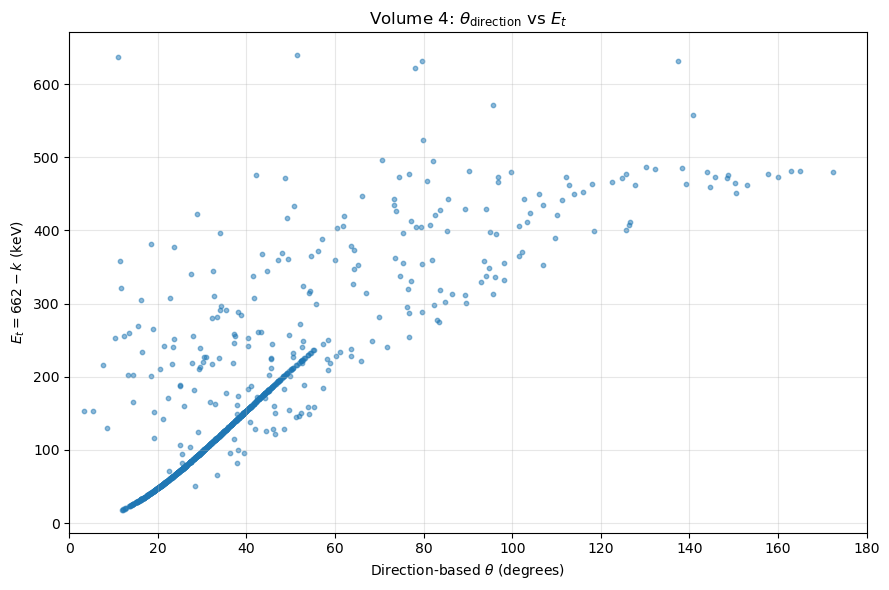

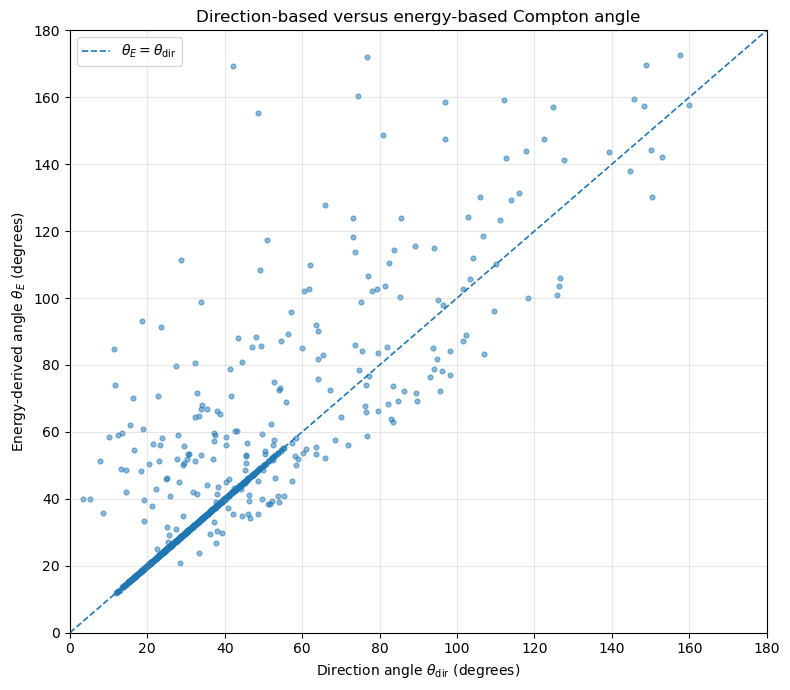

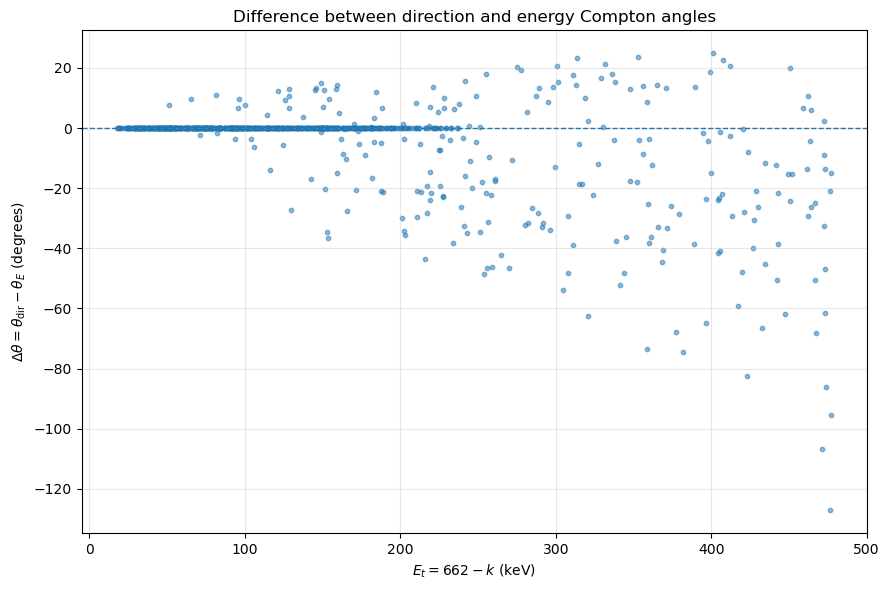

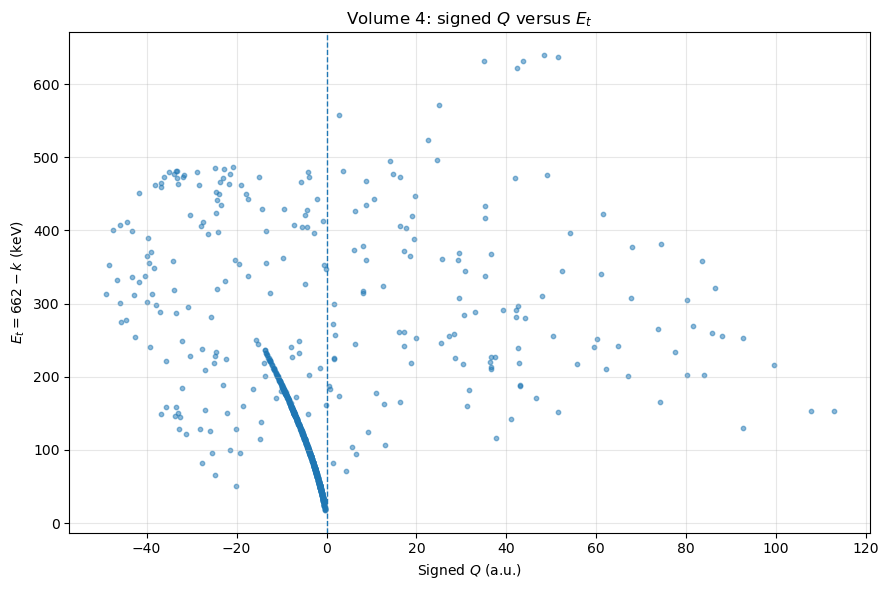

In [6]:
import ROOT
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import os

# ============================================================
# SETTINGS
# ============================================================

file_path = "/root/geant4/detector/Lung_Elements/HCO.root"
tree_name = "t"

selected_volume = 4
selected_pdg = 22

E0 = 662.0          # keV
ME = 511.0          # keV
P_AU = 3.72738      # keV/c per atomic unit

# Initial gamma direction
incident_direction = np.array(
    [0.0, -1.0, 0.0],
    dtype=float
)

incident_direction /= np.linalg.norm(
    incident_direction
)

output_csv = "HCO_vlm4_theta_Q_Et.csv"


# ============================================================
# OPEN ROOT FILE
# ============================================================

if not os.path.exists(file_path):
    raise FileNotFoundError(file_path)

root_file = ROOT.TFile.Open(file_path)

if not root_file or root_file.IsZombie():
    raise RuntimeError("Could not open ROOT file")

tree = root_file.Get(tree_name)

if not tree:
    raise RuntimeError("TTree 't' not found")

print("TTree entries =", tree.GetEntries())


# ============================================================
# STORAGE
# ============================================================

rows = []

n_vlm4_gamma = 0
n_valid = 0


# ============================================================
# EVENT LOOP
# ============================================================

for event_number, event in enumerate(tree):

    # Do NOT include et in n_core.
    # et can have a different vector length.
    n_core = min(
        len(event.pdg),
        len(event.vlm),
        len(event.trk),
        len(event.k),
        len(event.px),
        len(event.py),
        len(event.pz)
    )

    # First vlm=4 record for each gamma track
    counted_tracks = set()

    for i in range(n_core):

        # ----------------------------------------------------
        # VOLUME 4 + GAMMA
        # ----------------------------------------------------

        if int(event.vlm[i]) != selected_volume:
            continue

        if int(event.pdg[i]) != selected_pdg:
            continue

        n_vlm4_gamma += 1

        track_id = int(event.trk[i])

        # Keep first record in vlm 4 for this track
        if track_id in counted_tracks:
            continue

        counted_tracks.add(track_id)

        # ----------------------------------------------------
        # SCATTERED PHOTON ENERGY E' = k
        # ----------------------------------------------------

        Eprime = float(event.k[i])

        if (
            not np.isfinite(Eprime)
            or Eprime <= 0
            or Eprime > E0
        ):
            continue

        # Calculated energy transfer
        Et_calc = E0 - Eprime

        # ----------------------------------------------------
        # STORED et
        # ----------------------------------------------------

        stored_et = np.nan

        if i < len(event.et):

            value = float(event.et[i])

            if np.isfinite(value):
                stored_et = value

        # ----------------------------------------------------
        # OUTGOING GAMMA DIRECTION
        # ----------------------------------------------------

        px = float(event.px[i])
        py = float(event.py[i])
        pz = float(event.pz[i])

        pvec = np.array(
            [px, py, pz],
            dtype=float
        )

        pmag = np.linalg.norm(pvec)

        if (
            not np.isfinite(pmag)
            or pmag <= 0
        ):
            continue

        outgoing_direction = pvec / pmag

        # ====================================================
        # ANGLE 1:
        # DIRECTION-BASED ANGLE
        # ====================================================

        cos_theta_dir = np.dot(
            incident_direction,
            outgoing_direction
        )

        cos_theta_dir = np.clip(
            cos_theta_dir,
            -1.0,
            1.0
        )

        theta_direction = np.degrees(
            np.arccos(cos_theta_dir)
        )

        # ====================================================
        # ANGLE 2:
        # ENERGY-BASED FREE-ELECTRON COMPTON ANGLE
        #
        # cos(theta_E) =
        # 1 - ME*(1/E' - 1/E0)
        # ====================================================

        cos_theta_energy = (
            1.0
            - ME * (
                1.0 / Eprime
                - 1.0 / E0
            )
        )

        if -1.0 <= cos_theta_energy <= 1.0:

            theta_energy = np.degrees(
                np.arccos(cos_theta_energy)
            )

            delta_theta = (
                theta_direction
                - theta_energy
            )

        else:

            # Energy is inconsistent with an ideal
            # single free-electron Compton event
            theta_energy = np.nan
            delta_theta = np.nan

        # ----------------------------------------------------
        # PHOTON MOMENTUM TRANSFER q
        # ----------------------------------------------------

        q2 = (
            E0**2
            + Eprime**2
            - 2.0
            * E0
            * Eprime
            * cos_theta_dir
        )

        if (
            not np.isfinite(q2)
            or q2 <= 0
        ):
            continue

        q = np.sqrt(q2)

        # ----------------------------------------------------
        # LONGITUDINAL ELECTRON MOMENTUM Q
        # ----------------------------------------------------

        Q_keV_c = (
            ME / q
        ) * (
            Et_calc
            - q2 / (2.0 * ME)
        )

        Q_au = Q_keV_c / P_AU

        if not np.isfinite(Q_au):
            continue

        # ----------------------------------------------------
        # SAVE
        # ----------------------------------------------------

        rows.append({

            "event_number":
                event_number,

            "track_id":
                track_id,

            "record_index":
                i,

            "volume":
                int(event.vlm[i]),

            "pdg":
                int(event.pdg[i]),

            # energies
            "Eprime_k_keV":
                Eprime,

            "Et_662_minus_k_keV":
                Et_calc,

            "stored_et_keV":
                stored_et,

            # direction
            "px":
                px,

            "py":
                py,

            "pz":
                pz,

            # angles
            "theta_direction_deg":
                theta_direction,

            "theta_energy_deg":
                theta_energy,

            "delta_theta_deg":
                delta_theta,

            # q and Q
            "q_keV_c":
                q,

            "Q_keV_c":
                Q_keV_c,

            "Q_signed_au":
                Q_au,

            "Q_absolute_au":
                abs(Q_au)
        })

        n_valid += 1


root_file.Close()


# ============================================================
# DATAFRAME
# ============================================================

df = pd.DataFrame(rows)

if df.empty:
    raise RuntimeError(
        "No valid vlm=4 gamma records found."
    )

df.to_csv(
    output_csv,
    index=False
)

print("\nVolume 4 gamma records =", n_vlm4_gamma)
print("Valid unique gamma tracks =", n_valid)

print(
    "Valid stored et values =",
    df["stored_et_keV"].notna().sum()
)

print(
    "Valid energy-angle values =",
    df["theta_energy_deg"].notna().sum()
)

print("\nSaved:")
print(os.path.abspath(output_csv))

print("\nFirst rows:")
display(df.head(10))


# ============================================================
# PLOT 1
# DIRECTION ANGLE vs CALCULATED Et
# ============================================================

plt.figure(figsize=(9, 6))

plt.scatter(
    df["theta_direction_deg"],
    df["Et_662_minus_k_keV"],
    s=10,
    alpha=0.5
)

plt.xlabel(
    r"Direction-based $\theta$ (degrees)"
)

plt.ylabel(
    r"$E_t = 662-k$ (keV)"
)

plt.title(
    r"Volume 4: $\theta_{\rm direction}$ vs $E_t$"
)

plt.xlim(0, 180)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# PLOT 2
# ENERGY ANGLE vs DIRECTION ANGLE
# ============================================================

angle_df = df.dropna(
    subset=[
        "theta_direction_deg",
        "theta_energy_deg"
    ]
)

plt.figure(figsize=(8, 7))

plt.scatter(
    angle_df["theta_direction_deg"],
    angle_df["theta_energy_deg"],
    s=12,
    alpha=0.5
)

# y = x reference
plt.plot(
    [0, 180],
    [0, 180],
    "--",
    linewidth=1.2,
    label=r"$\theta_E=\theta_{\rm dir}$"
)

plt.xlabel(
    r"Direction angle $\theta_{\rm dir}$ (degrees)"
)

plt.ylabel(
    r"Energy-derived angle $\theta_E$ (degrees)"
)

plt.title(
    "Direction-based versus energy-based Compton angle"
)

plt.xlim(0, 180)
plt.ylim(0, 180)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# PLOT 3
# DELTA THETA vs Et
# ============================================================

plt.figure(figsize=(9, 6))

plt.scatter(
    angle_df["Et_662_minus_k_keV"],
    angle_df["delta_theta_deg"],
    s=10,
    alpha=0.5
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel(
    r"$E_t = 662-k$ (keV)"
)

plt.ylabel(
    r"$\Delta\theta="
    r"\theta_{\rm dir}-\theta_E$ (degrees)"
)

plt.title(
    r"Difference between direction and energy Compton angles"
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# PLOT 4
# SIGNED Q vs Et
# ============================================================

plt.figure(figsize=(9, 6))

plt.scatter(
    df["Q_signed_au"],
    df["Et_662_minus_k_keV"],
    s=10,
    alpha=0.5
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel(
    r"Signed $Q$ (a.u.)"
)

plt.ylabel(
    r"$E_t=662-k$ (keV)"
)

plt.title(
    r"Volume 4: signed $Q$ versus $E_t$"
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

TTree entries = 100000

Saved:
/root/geant4/detector/Lung_Elements/HCO_vlm4_gamma_theta_energy.csv
/root/geant4/detector/Lung_Elements/HCO_vlm4_event_stored_et.csv

Gamma records = 1134
Stored et entries = 3771

Gamma CSV columns:
['event_number', 'record_index', 'vlm', 'pdg', 'Eprime_k_keV', 'Et_662_minus_k_keV', 'theta_energy_deg', 'theta_direction_deg', 'delta_theta_deg', 'px', 'py', 'pz']

et CSV columns:
['event_number', 'et_index', 'stored_et_keV', 'number_of_vlm4_gamma_records']


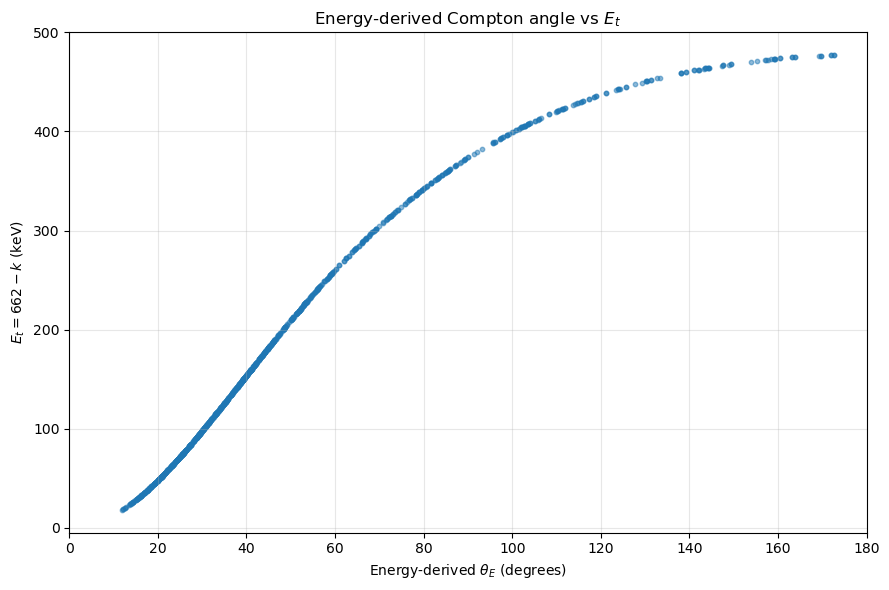

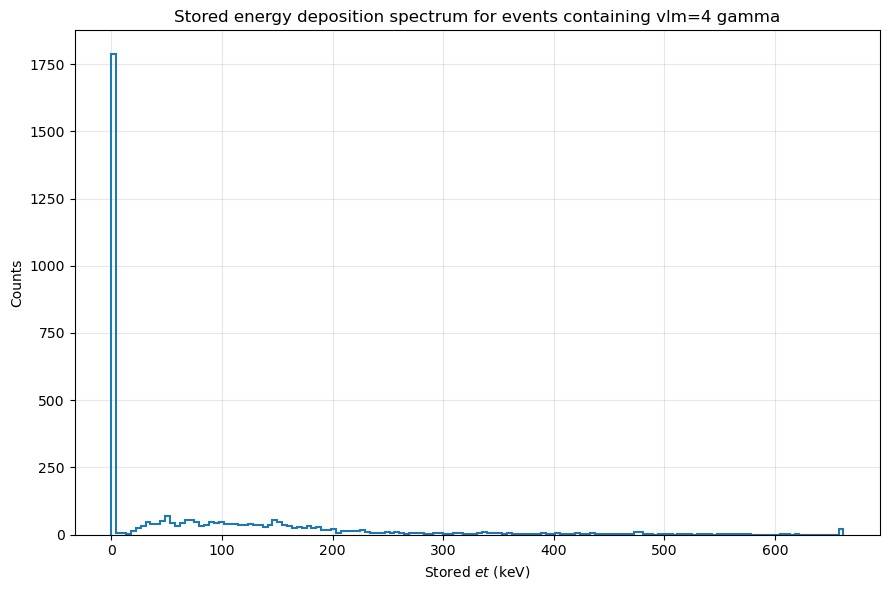

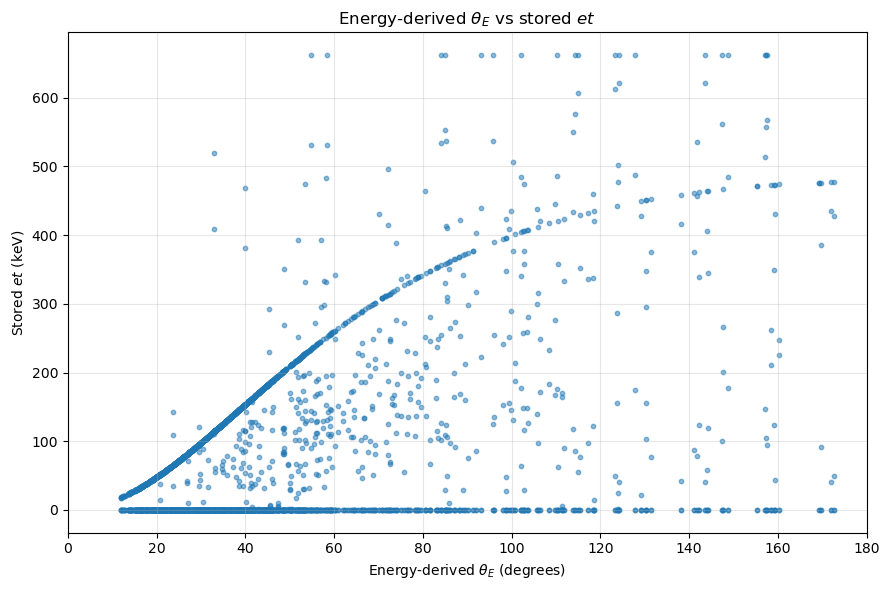

In [7]:
import ROOT
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# =====================================================
# SETTINGS
# =====================================================

file_path = "/root/geant4/detector/Lung_Elements/HCO.root"
tree_name = "t"

E0 = 662.0
ME = 511.0

selected_volume = 4
selected_pdg = 22

gamma_csv = "HCO_vlm4_gamma_theta_energy.csv"
et_csv = "HCO_vlm4_event_stored_et.csv"

# =====================================================
# OPEN ROOT FILE
# =====================================================

root_file = ROOT.TFile.Open(file_path)

if not root_file or root_file.IsZombie():
    raise RuntimeError("Could not open ROOT file")

tree = root_file.Get(tree_name)

if not tree:
    raise RuntimeError("TTree 't' not found")

print("TTree entries =", tree.GetEntries())

# =====================================================
# STORAGE
# =====================================================

gamma_rows = []
et_rows = []

# =====================================================
# EVENT LOOP
# =====================================================

for event_number, event in enumerate(tree):

    n_core = min(
        len(event.pdg),
        len(event.vlm),
        len(event.k),
        len(event.px),
        len(event.py),
        len(event.pz)
    )

    # -------------------------------------------------
    # Find vlm=4 gamma records in this event
    # -------------------------------------------------

    event_gamma_rows = []

    for i in range(n_core):

        if int(event.vlm[i]) != selected_volume:
            continue

        if int(event.pdg[i]) != selected_pdg:
            continue

        Eprime = float(event.k[i])

        if (
            not np.isfinite(Eprime)
            or Eprime <= 0.0
            or Eprime > E0
        ):
            continue

        # =============================================
        # Et calculated from photon energy
        # =============================================

        Et_calc = E0 - Eprime

        # =============================================
        # Energy-derived Compton angle
        # =============================================

        cos_theta_E = (
            1.0
            - ME * (
                1.0 / Eprime
                - 1.0 / E0
            )
        )

        if -1.0 <= cos_theta_E <= 1.0:

            theta_energy = np.degrees(
                np.arccos(cos_theta_E)
            )

        else:

            theta_energy = np.nan

        # =============================================
        # Direction-derived angle
        # =============================================

        px = float(event.px[i])
        py = float(event.py[i])
        pz = float(event.pz[i])

        p = np.sqrt(
            px**2 + py**2 + pz**2
        )

        theta_direction = np.nan

        if np.isfinite(p) and p > 0:

            # Incident direction = (0,-1,0)
            cos_theta_dir = -py / p

            cos_theta_dir = np.clip(
                cos_theta_dir,
                -1.0,
                1.0
            )

            theta_direction = np.degrees(
                np.arccos(cos_theta_dir)
            )

        row = {
            "event_number": event_number,
            "record_index": i,

            "vlm": int(event.vlm[i]),
            "pdg": int(event.pdg[i]),

            "Eprime_k_keV": Eprime,

            "Et_662_minus_k_keV":
                Et_calc,

            "theta_energy_deg":
                theta_energy,

            "theta_direction_deg":
                theta_direction,

            "delta_theta_deg":
                theta_direction - theta_energy
                if (
                    np.isfinite(theta_direction)
                    and np.isfinite(theta_energy)
                )
                else np.nan,

            "px": px,
            "py": py,
            "pz": pz
        }

        gamma_rows.append(row)
        event_gamma_rows.append(row)

    # -------------------------------------------------
    # STORED et VALUES
    #
    # Only use them if this event contains vlm=4 gamma.
    # -------------------------------------------------

    if len(event_gamma_rows) > 0:

        for et_index in range(len(event.et)):

            et_value = float(
                event.et[et_index]
            )

            if not np.isfinite(et_value):
                continue

            et_rows.append({
                "event_number":
                    event_number,

                "et_index":
                    et_index,

                "stored_et_keV":
                    et_value,

                "number_of_vlm4_gamma_records":
                    len(event_gamma_rows)
            })


root_file.Close()

# =====================================================
# DATAFRAMES
# =====================================================

gamma_df = pd.DataFrame(
    gamma_rows
)

et_df = pd.DataFrame(
    et_rows
)

if gamma_df.empty:
    raise RuntimeError(
        "No vlm=4 gamma records found."
    )

if et_df.empty:
    print(
        "Warning: no stored et values found "
        "in events containing vlm=4 gamma."
    )

# =====================================================
# SAVE CSV FILES
# =====================================================

gamma_df.to_csv(
    gamma_csv,
    index=False
)

et_df.to_csv(
    et_csv,
    index=False
)

print("\nSaved:")
print(os.path.abspath(gamma_csv))
print(os.path.abspath(et_csv))

print("\nGamma records =", len(gamma_df))
print("Stored et entries =", len(et_df))

print("\nGamma CSV columns:")
print(gamma_df.columns.tolist())

print("\net CSV columns:")
print(et_df.columns.tolist())

# =====================================================
# PLOT 1
# ENERGY-DERIVED THETA vs Et = 662-k
# =====================================================

plot1 = gamma_df.dropna(
    subset=[
        "theta_energy_deg",
        "Et_662_minus_k_keV"
    ]
)

plt.figure(figsize=(9, 6))

plt.scatter(
    plot1["theta_energy_deg"],
    plot1["Et_662_minus_k_keV"],
    s=10,
    alpha=0.5
)

plt.xlabel(
    r"Energy-derived $\theta_E$ (degrees)"
)

plt.ylabel(
    r"$E_t=662-k$ (keV)"
)

plt.title(
    r"Energy-derived Compton angle vs $E_t$"
)

plt.xlim(0, 180)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# =====================================================
# PLOT 2
# STORED et vs COUNTS
# =====================================================

if not et_df.empty:

    plt.figure(figsize=(9, 6))

    plt.hist(
        et_df["stored_et_keV"],
        bins=150,
        histtype="step",
        linewidth=1.5
    )

    plt.xlabel(
        r"Stored $et$ (keV)"
    )

    plt.ylabel(
        "Counts"
    )

    plt.title(
        "Stored energy deposition spectrum "
        "for events containing vlm=4 gamma"
    )

    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

# =====================================================
# PLOT 3
# ENERGY-DERIVED THETA vs STORED et
#
# Event-level matching
# =====================================================

if not et_df.empty:

    # First gamma-derived angle in each event
    event_theta = (
        gamma_df
        .dropna(
            subset=["theta_energy_deg"]
        )
        .groupby(
            "event_number",
            as_index=False
        )
        .first()[
            [
                "event_number",
                "theta_energy_deg"
            ]
        ]
    )

    theta_et_df = et_df.merge(
        event_theta,
        on="event_number",
        how="inner"
    )

    plt.figure(figsize=(9, 6))

    plt.scatter(
        theta_et_df[
            "theta_energy_deg"
        ],
        theta_et_df[
            "stored_et_keV"
        ],
        s=10,
        alpha=0.5
    )

    plt.xlabel(
        r"Energy-derived $\theta_E$ (degrees)"
    )

    plt.ylabel(
        r"Stored $et$ (keV)"
    )

    plt.title(
        r"Energy-derived $\theta_E$ vs stored $et$"
    )

    plt.xlim(0, 180)

    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()